In [1]:
import numpy as np
import pandas as pd
import osmnx as ox
import matplotlib.pyplot as plt

import imn_generation
import imn_loading
from map_matching import map_match_valhalla_all, points_to_osmnx_routes, read_osmnx_routes
from experiments.trajectory_analysis import dtw_overlap_all, get_route_edge_attributes, get_local_adjusted_edge_attributes
from personalized_routing import add_edge_attributes, compare_fastest, learn_user_preferences

# Loading the data

In [5]:
# Using a sample dataset of Milan, Italy
points_df = pd.read_csv('data/sample_Milan_2007.csv.gz').rename(columns={
    'userid':'id', 
    'datetime':'timestamp',
    'lon':'longitude', 
    'lat':'latitude'
})

# Convert timestamp string to Epoch in seconds
points_df['timestamp'] = pd.to_datetime(points_df['timestamp']).values.astype(np.int64) // 10 ** 9
points_df.head()

,id,timestamp,latitude,longitude
0,1059,1175759222,45.474777,9.210948
1,1059,1175760960,45.474777,9.210948
2,1059,1175762693,45.474777,9.210948
3,1059,1175782974,45.474777,9.210948
4,1059,1175794229,45.474777,9.210948


In [4]:
# Download and save the OSM graph for the area of interest
# Buffer around to avoid cutting off edges at the border
bufsize = 0.01
bbox = (np.min(points_df['longitude'] - bufsize),
         np.min(points_df['latitude'] - bufsize),
         np.max(points_df['longitude'] + bufsize),
         np.max(points_df['latitude'] + bufsize))

G = ox.graph_from_bbox(bbox, network_type='drive', simplify=False)
G = ox.truncate.largest_component(G, strongly=True)
G = add_edge_attributes(G)
ox.save_graphml(G, 'data/milano_2007_graph.graphml')

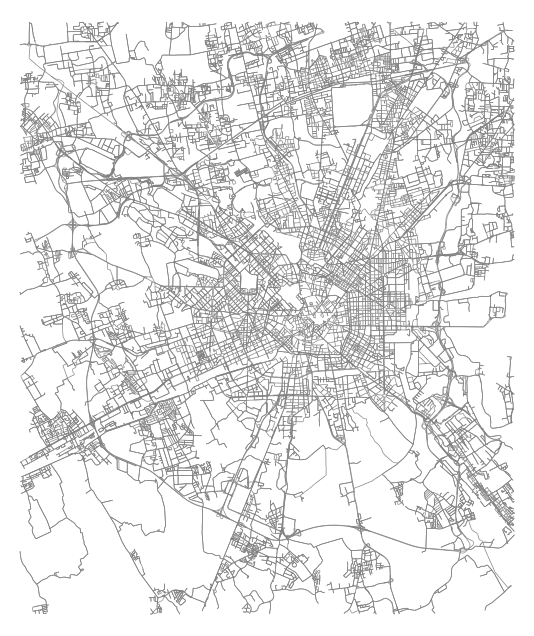

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.5, edge_color='gray', bgcolor='white')

# Constructing the IMN + map-matching

In [6]:
# IMN generation takes care of segmentation
# Also removes blatant errors in trajectories
# and excludes users with too little history (< 10 trajs)
imn_generation.main_from_code(points_df, 'data/milano_2007_imns.json.gz')

--- 0.19730901718139648 seconds Location Extraction ---
IMN created for 650 with 11 trajectories
--- 0.288470983505249 seconds Location Extraction ---
IMN created for 1575 with 16 trajectories
--- 0.11234307289123535 seconds Location Extraction ---
IMN created for 1607 with 11 trajectories
--- 0.3289179801940918 seconds Location Extraction ---
IMN created for 2133 with 12 trajectories
--- 0.20944690704345703 seconds Location Extraction ---
IMN created for 2565 with 18 trajectories
--- 0.2043781280517578 seconds Location Extraction ---
IMN created for 3695 with 11 trajectories
--- 0.14929986000061035 seconds Location Extraction ---
IMN created for 3703 with 12 trajectories
--- 0.1427931785583496 seconds Location Extraction ---
IMN created for 5892 with 16 trajectories
--- 0.16150307655334473 seconds Location Extraction ---
IMN created for 5902 with 11 trajectories
--- 0.1948540210723877 seconds Location Extraction ---
IMN created for 7308 with 13 trajectories
--- 0.47687292098999023 sec

In [3]:
imns = imn_loading.read_imn('data/milano_2007_imns.json.gz')
segmented_trajs = imn_loading.get_trajectories_from_imns(imns)

In [4]:
# 1st step: map-match
# Must have constructed the tile extracts for Valhalla in advance, see README
map_match_valhalla_all(segmented_trajs,
                       output_path='data/milano_2007_mapmatched.csv.gz',
                       tile_extract='valhalla/valhalla_tiles.tar',
                       verbose=True)

Starting Valhalla map-matching
Users:   0%|          | 0/248 [00:00<?, ?it/s]

Users: 100%|██████████| 248/248 [07:11<00:00,  1.74s/it]
Valhalla map-matching completed


In [5]:
# 2nd step: convert map-matched points to OSMnx routes
G = ox.load_graphml('data/milano_2007_graph.graphml')
points_to_osmnx_routes(G,
                       input_path='data/milano_2007_mapmatched.csv.gz',
                       output_path='data/milano_2007_routes.csv.gz',
                       verbose=True)

Starting conversion to osmnx routes
Users: 100%|██████████| 248/248 [00:33<00:00,  7.33it/s]
Conversion to osmnx routes completed


In [6]:
routes = read_osmnx_routes('data/milano_2007_routes.csv.gz')

### Example route visualization
Plotting the same route: before map-matching and after map-matching

In [15]:
from experiments.trajectory_analysis import get_route_bbox

In [21]:
for key, value in routes[650].items():
    print(key, len(value['nodes']))

0 30
1 197
2 353
3 242
4 191
5 302
6 301
7 824
8 679
10 643
11 319


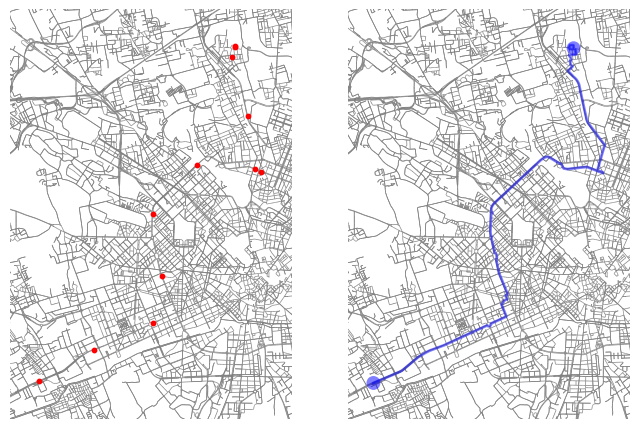

In [25]:
orig_route = segmented_trajs[650].query('id == 8')
osmnx_route = routes[650][8]['nodes']

bbox = get_route_bbox(G, [osmnx_route])

# Original points
fig, ax = plt.subplots(1,2, figsize=(8,6))
ox.plot_graph(G, ax=ax[0],
              edge_color='gray',
              bgcolor='white',
              edge_linewidth=0.5, node_size=0,
              bbox=bbox,
              close=False,
              show=False)
ax[0].scatter(orig_route['longitude'], orig_route['latitude'], c='red', s=10)

# Route
ox.plot_graph(
    G, ax=ax[1],
    edge_color='gray', bgcolor='white',
    edge_linewidth=0.5, node_size=0,
    bbox=bbox, close=False, show=False
)
ox.plot_graph_route(G, osmnx_route, ax=ax[1],
                    route_color='blue',
                    edge_color='gray',
                    bgcolor='white',
                    edge_linewidth=0.5,
                    route_linewidth=2, node_size=0,
                    bbox=bbox,
                    close=False,
                    show=False)

plt.show()

# Data exploration

In [2]:
G = ox.load_graphml('data/milano_2007_graph.graphml')
routes = read_osmnx_routes('data/milano_2007_routes.csv.gz')

### DTW/Jaccard

In [ ]:
dtw_overlap_all(G,
                routes,
                filename='data/milano_2007_dtw_overlap.csv.gz',
                # num_processes=1,
                verbose=True)

/opt/miniconda3/envs/thesis/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/opt/miniconda3/envs/thesis/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/opt/miniconda3/envs/thesis/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/opt/miniconda3/envs/thesis/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
/opt/miniconda3/envs/thesis/lib/python3.10/site-packages/tslearn/bases/bases.py:15: User

In [2]:
dtw_overlap = pd.read_csv('data/milano_2007_dtw_overlap.csv.gz')

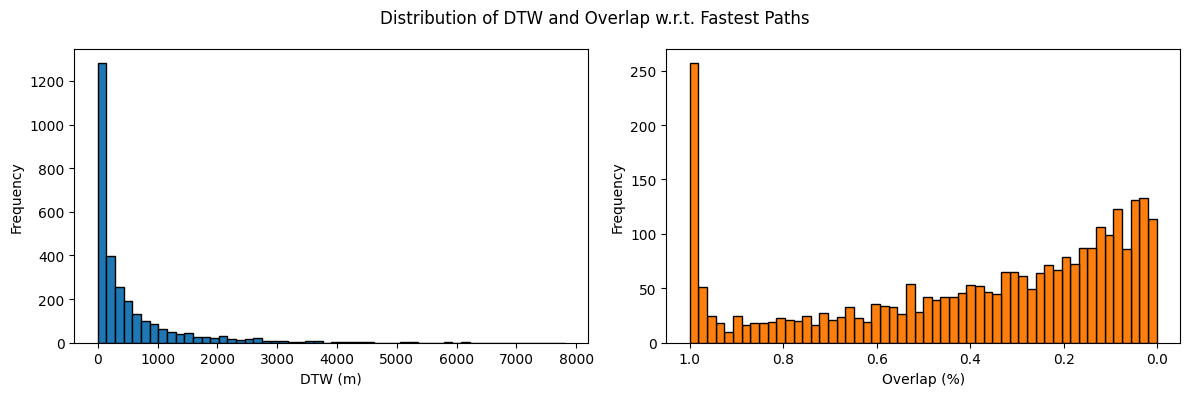

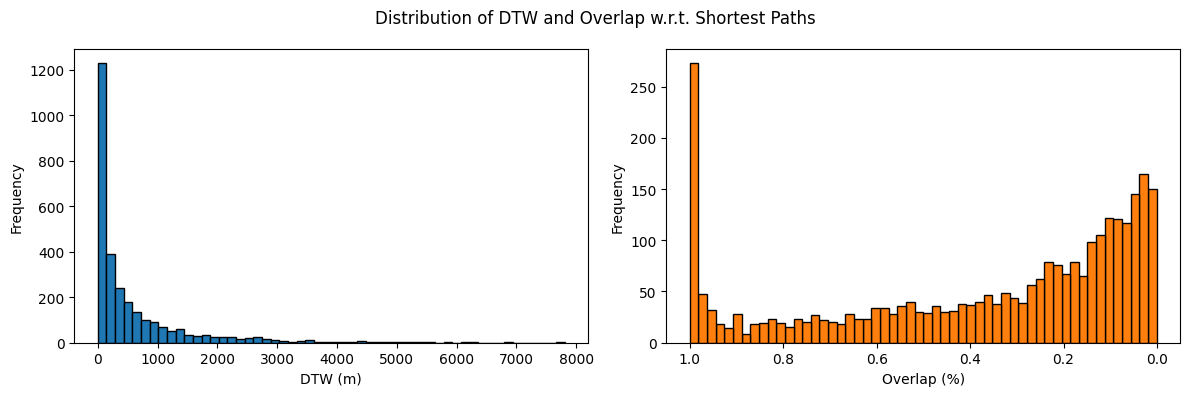

In [15]:
# Distribution of DTW and Jaccard
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(dtw_overlap['dtw_travel_time'], bins='sqrt', edgecolor='black', color='tab:blue')
ax[0].set_xlabel('DTW (m)')
ax[0].set_ylabel('Frequency')

ax[1].hist(dtw_overlap['overlap_travel_time'], bins='sqrt', edgecolor='black', color='tab:orange')
ax[1].invert_xaxis()
ax[1].set_xlabel('Overlap (%)')
ax[1].set_ylabel('Frequency')

fig.suptitle('Distribution of DTW and Overlap w.r.t. Fastest Paths')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(dtw_overlap['dtw_length'], bins='sqrt', edgecolor='black', color='tab:blue')
ax[0].set_xlabel('DTW (m)')
ax[0].set_ylabel('Frequency')

ax[1].hist(dtw_overlap['overlap_length'], bins='sqrt', edgecolor='black', color='tab:orange')
ax[1].invert_xaxis()
ax[1].set_xlabel('Overlap (%)')
ax[1].set_ylabel('Frequency')

fig.suptitle('Distribution of DTW and Overlap w.r.t. Shortest Paths')
plt.tight_layout()
plt.show()

### Edge-by-edge attributes

In [ ]:
get_route_edge_attributes(G,
                          routes,
                          center={'y': 45.46823695109099, 'x': 9.182262786187506},
                          filename_real='data/milano_2007_attr_real.csv.gz',
                          filename_fastest='data/milano_2007_attr_fastest.csv.gz',
                          verbose=True)      

In [ ]:
real_df = pd.read_csv('data/milano_2007_attr_real.csv.gz')
fastest_df = pd.read_csv('data/milano_2007_attr_fastest.csv.gz')

In [ ]:
# Example: plotting histograms
attributes = [
    'length',
    'speed_kph',
    'travel_time',
    'residential',
    'motorway',
    'stop_short',
    'stop_medium',
    'stop_long',
    'flow_low',
    'flow_medium',
    'flow_high',
    'water',
    'landuse_green',
    'landuse_commercial',
    'landuse_residential',
    'landuse_industrial',
]

real_df_grouped = real_df.groupby('uid')[attributes].mean()
fastest_df_grouped = fastest_df.groupby('uid')[attributes].mean()

fig, ax = plt.subplots(4, 4, figsize=(20,20))
for i, attr in enumerate(attributes):
    real_data = real_df_grouped[attr]
    fastest_data = fastest_df_grouped[attr]

    bins = np.histogram(np.hstack((real_data, fastest_data)), bins=int(4*np.log2(len(real_data))+1))[1]
    
    ax[i//4, i%4].hist(real_data, bins=bins, edgecolor='black', alpha=0.5, label='real')
    ax[i//4, i%4].hist(fastest_data, bins=bins, edgecolor='black', alpha=0.5, label='fastest')
    ax[i//4, i%4].set_title(attr)
    ax[i//4, i%4].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Testing a fixed beta value for local adjustment
cost_attributes = ['residential', 'landuse_industrial', 'landuse_commercial', 'flow_low', 'water']
get_local_adjusted_edge_attributes(G,
                                   routes,
                                   beta=1.0,
                                   cost_attributes=cost_attributes,
                                   filename_adjusted='data/milano_2007_attr_adjusted_1.0.csv.gz',
                                   filename_alphas='data/milano_2007_alphas.json',
                                   # num_processes=1,
                                   verbose=True)

# Running the iterative method

In [ ]:
# Aggregated edge attributes + alphas
# Real data also includes the attributes necessary for clustering
compare_fastest(G,
                routes,
                real_path='data/milano_2007_aggregated_real.csv.gz',
                fastest_path='data/milano_2007_aggregated_fastest.csv.gz',
                alphas_path='data/milano_2007_alphas.json',
                # num_processes=1,
                verbose=True)

### Identifying clusters

In [ ]:
from scipy.cluster.hierarchy import dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [ ]:
def percentile(n):
    def percentile_(x):
        return x.quantile(n)
    percentile_.__name__ = 'percentile_{:02.0f}'.format(n*100)
    return percentile_


def get_linkage_matrix(model):
    counts = np.zeros(model.children_.shape[0])
    
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    return linkage_matrix

def plot_dendrogram(model, **kwargs):
    linkage_matrix = get_linkage_matrix(model)
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
# TODO cluster

In [ ]:
cost_attributes = ['residential', 'landuse_industrial', 'landuse_commercial', 'flow_low', 'water']

learn_user_preferences(G,
                       routes,
                       cost_attributes,
                       alphas_path='data/milano_2007_alphas.json',
                       real_path='data/milano_2007_attr_real.csv.gz',
                       results_dir='data/milano_results/',
                       iterations=5,
                       cluster_to_uid=cluster_to_uid,
                       verbose=True)